<a href="https://colab.research.google.com/github/asternoeld/practical-ml-25-26/blob/main/assignment1/wine_quality_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
!pip install ucimlrepo

In [37]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from ucimlrepo import fetch_ucirepo

In [38]:
torch.manual_seed(42)
np.random.seed(42)

In [39]:
# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# features (inputs)
X = wine_quality.data.features

# targets (output)
y = wine_quality.data.targets

print(X.head())
print(y.head())
print(X.shape)

   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8  
4      9.4  
   quali

In [40]:
X = X.values
y = y.values

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [42]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

In [44]:
dataset = TensorDataset(X_train, y_train)

batch_size = 32

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

In [45]:
model = nn.Sequential(
    nn.Linear(11, 64),
    nn.ReLU(),

    nn.Linear(64, 32),
    nn.ReLU(),

    nn.Linear(32, 1)
)

In [46]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [47]:
epochs = 100
losses = []

for epoch in range(epochs):

    epoch_loss = 0

    for xb, yb in loader:

        preds = model(xb)

        loss = loss_fn(preds, yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(loader)

    losses.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} Loss {epoch_loss:.4f}")

Epoch 0 Loss 9.4430
Epoch 10 Loss 0.4894
Epoch 20 Loss 0.4593
Epoch 30 Loss 0.4439
Epoch 40 Loss 0.4317
Epoch 50 Loss 0.4211
Epoch 60 Loss 0.4120
Epoch 70 Loss 0.4059
Epoch 80 Loss 0.3966
Epoch 90 Loss 0.3952


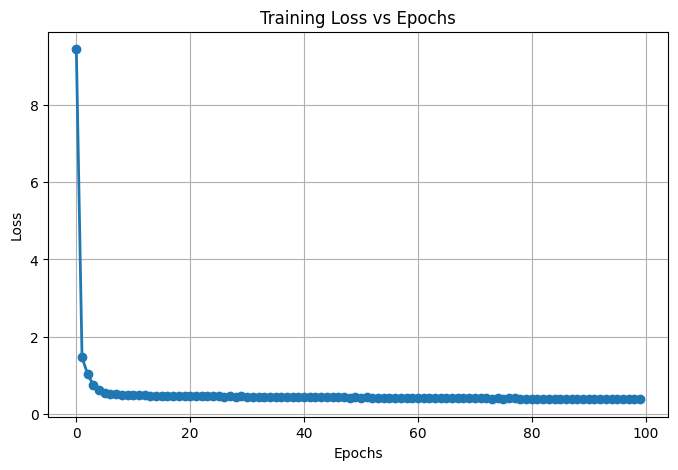

In [48]:
plt.figure(figsize=(8,5))

plt.plot(losses, marker='o', linewidth=2)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")

plt.grid()

plt.show()

In [49]:
with torch.no_grad():
    y_pred = model(X_test)

y_pred = y_pred.numpy()
y_true = y_test.numpy()

In [50]:
test_loss = loss_fn(torch.tensor(y_pred), y_test).item()

r2 = r2_score(y_true, y_pred)

print("Test Loss:", test_loss)
print("R2 Score:", r2)

Test Loss: 0.4903741776943207
R2 Score: 0.3360280990600586


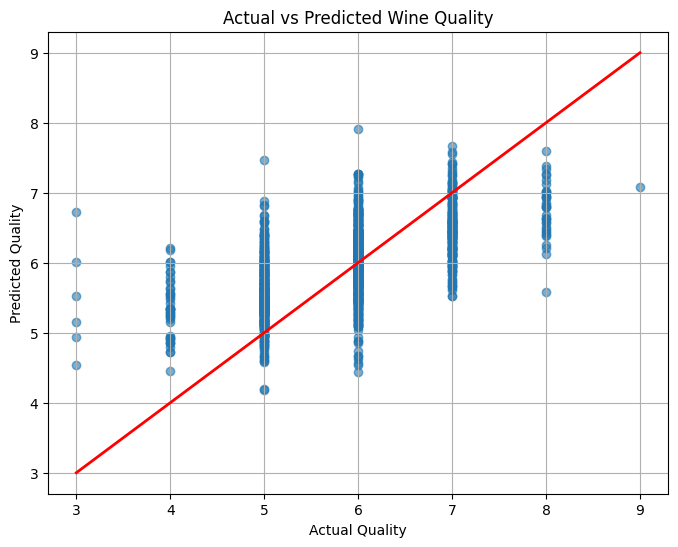

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_true,
    y_pred,
    alpha=0.6
)

plt.plot([3,9],[3,9], color='red', linewidth=2)

plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")

plt.title("Actual vs Predicted Wine Quality")

plt.grid()

plt.show()